# Dự đoán Điểm thi Kết thúc học phần sử dụng Machine Learning & Graph Neural Networks (GNNs)

Notebook này trình bày cách dự đoán điểm thi kết thúc học phần của sinh viên thông qua sự kết hợp của **kết quả học tập cá nhân (academic performance)**, **điểm số của bạn bè (peer scores)** và **tín hiệu từ mạng xã hội học tập (social network signals)**.

## Các nhiệm vụ chính (5 Tasks):
1. **Xây dựng tập dữ liệu kèm ảnh hưởng từ bạn bè**: Tạo hồ sơ giả lập cho 3,000 sinh viên (gồm 5 điểm học tập và 10 điểm của bạn bè) và xây dựng đồ thị mạng lưới dựa trên sự tương đồng học lực.
2. **Huấn luyện các mô hình**: Triển khai và huấn luyện 4 mô hình:
   - **V1: Gradient Boosting Regressor** (Mô hình học máy dạng cây Boosting truyền thống với đặc trưng trung bình bạn bè)
   - **V2: MLP (GNN-style)** (Mạng nơ-ron PyTorch sử dụng đặc trưng cá nhân kết hợp các chỉ số thống kê bạn bè, chạy trên GPU)
   - **V3: GraphSAGE GNN** (Mạng nơ-ron đồ thị PyTorch sử dụng phép tổng hợp lân cận, chạy trên GPU)
   - **V4: Random Forest Regressor** (Mô hình Baseline dạng rừng ngẫu nhiên)
3. **Đánh giá bằng 5 chỉ số**: Tính toán MAE, MSE, RMSE, MAPE và $R^2$ để so sánh các mô hình.
4. **So sánh dưới các cấu trúc xã hội khác nhau**: Phân tích hiệu năng của GraphSAGE thay đổi thế nào khi ta biến đổi ngưỡng tương đồng (thay đổi độ thưa/dày đặc của đồ thị mạng lưới bạn bè).
5. **Phân tích sự lan truyền ảnh hưởng từ bạn bè**: Mô phỏng kịch bản nhóm bạn tăng điểm (+2 điểm) và phân tích sự lan truyền thay đổi dự đoán trong GraphSAGE (GNN) so với MLP.

---

## Thiết lập & Khai báo Thư viện
Chúng ta khai báo các thư viện học máy phổ biến, PyTorch, và thiết lập seed ngẫu nhiên nhằm đảm bảo tính tái lập kết quả huấn luyện. Đồng thời kích hoạt tăng tốc GPU (CUDA) nếu khả dụng.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import copy

# Thiết lập seed để đảm bảo tính tái lập
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị huấn luyện sử dụng: {device}")

# Tạo các thư mục lưu kết quả
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

Thiết bị huấn luyện sử dụng: cpu


## Nhiệm vụ 1: Xây dựng tập dữ liệu kèm ảnh hưởng từ bạn bè

Chúng ta tạo tập dữ liệu giả lập cho $N = 3000$ sinh viên. Mỗi sinh viên bao gồm:
- 5 điểm số học thuật (Java, Python, Cấu trúc dữ liệu, Phân tích thiết kế hệ thống, Phát triển hệ thống thông minh) có khoảng điểm từ 4 đến 10.
- 10 điểm số đánh giá từ bạn bè có khoảng điểm từ 4 đến 10.

Chúng ta xây dựng ma trận kề $A$ biểu diễn liên kết bạn bè dựa trên khoảng cách học lực (Euclidean distance). Một liên kết tồn tại nếu khoảng cách nhỏ hơn ngưỡng 6.0. Ma trận sau đó được chuẩn hóa theo dòng.

Điểm số FinalExam được sinh dựa trên công thức:
$$\text{Điểm} = 0.25 \times \text{Java} + 0.20 \times \text{Python} + 0.10 \times \text{DS} + 0.15 \times \text{SAD} + 0.10 \times \text{ISD} + 0.15 \times \text{peer\_mean} - 0.05 \times \text{peer\_std} + 0.05 \times \text{peer\_mean\_graph} + \epsilon$$
trong đó $\epsilon \sim \mathcal{N}(0, 0.25^2)$ là nhiễu ngẫu nhiên.

In [2]:
N = 3000

# Sinh 5 cột điểm học lực học tập cá nhân
X_academic = np.random.randint(4, 11, size=(N, 5))

# Sinh 10 điểm từ bạn bè
X_peer = np.random.randint(4, 11, size=(N, 10))

# Gộp lại thành ma trận đặc trưng thô X
X = np.hstack([X_academic, X_peer])

# Tính toán thống kê bạn bè trực tiếp
peer_mean = X_peer.mean(axis=1)
peer_std = X_peer.std(axis=1)

# Xây dựng đồ thị liên kết bằng khoảng cách Euclidean (Tối ưu vector hóa)
dists = cdist(X_academic, X_academic, metric='euclidean')
threshold = 6.0
A = (dists < threshold).astype(float)
np.fill_diagonal(A, 0) # Loại bỏ tự liên kết với chính mình

# Chuẩn hóa ma trận kề theo dòng
A_sum = A.sum(axis=1, keepdims=True)
A_norm = A / (A_sum + 1e-6)

# Tổng hợp ảnh hưởng bạn bè qua đồ thị mạng lưới
neigh_peer = np.matmul(A_norm, X_peer)
peer_mean_graph = neigh_peer.mean(axis=1)

# Tính điểm thi cuối kỳ (Target)
y = (
    0.25 * X_academic[:, 0] +  # java
    0.20 * X_academic[:, 1] +  # python
    0.10 * X_academic[:, 2] +  # ds
    0.15 * X_academic[:, 3] +  # sad
    0.10 * X_academic[:, 4] +  # isd
    0.15 * peer_mean -
    0.05 * peer_std +
    0.05 * peer_mean_graph +
    np.random.normal(0, 0.25, N)
)
y = np.clip(y, 4.0, 10.0) # Giới hạn điểm cuối kỳ trong khoảng thực tế [4, 10]

# Tạo Pandas DataFrame để phân tích dữ liệu & huấn luyện mô hình cây
columns = [
    'javaProg', 'pythonProg', 'dataStructure', 'softwareAnalysisDesign', 'intelligenceSystemDev',
    'peer1', 'peer2', 'peer3', 'peer4', 'peer5', 'peer6', 'peer7', 'peer8', 'peer9', 'peer10'
]
df = pd.DataFrame(X, columns=columns)
df['peer_mean'] = peer_mean
df['peer_std'] = peer_std
df['peer_mean_graph'] = peer_mean_graph
df['FinalExam'] = y

df.to_csv('student_scores_dataset.csv', index=False)
print("Đã xây dựng và lưu tập dữ liệu thành công. Kích thước:", df.shape)

Đã xây dựng và lưu tập dữ liệu thành công. Kích thước: (3000, 19)


## Nhiệm vụ 2: Phân tích Khám phá Dữ liệu (EDA)

Chúng ta vẽ biểu đồ phân phối của điểm số FinalExam và các môn học thuật cá nhân, đồng thời tính toán và trực quan hóa ma trận tương quan giữa các đặc trưng.

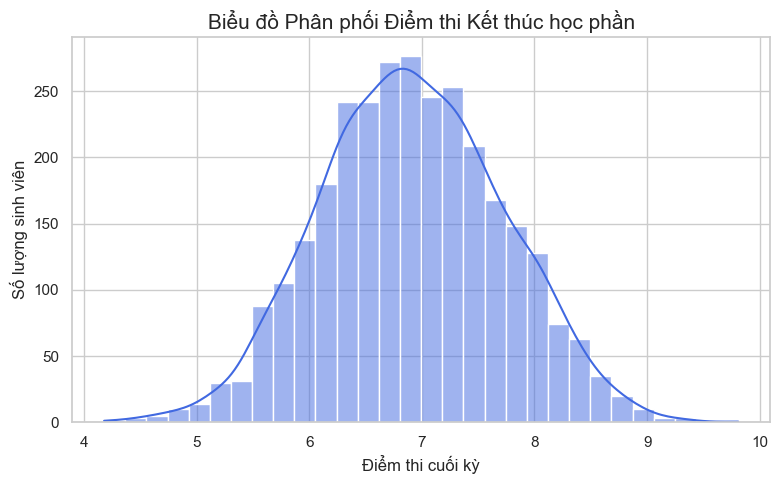

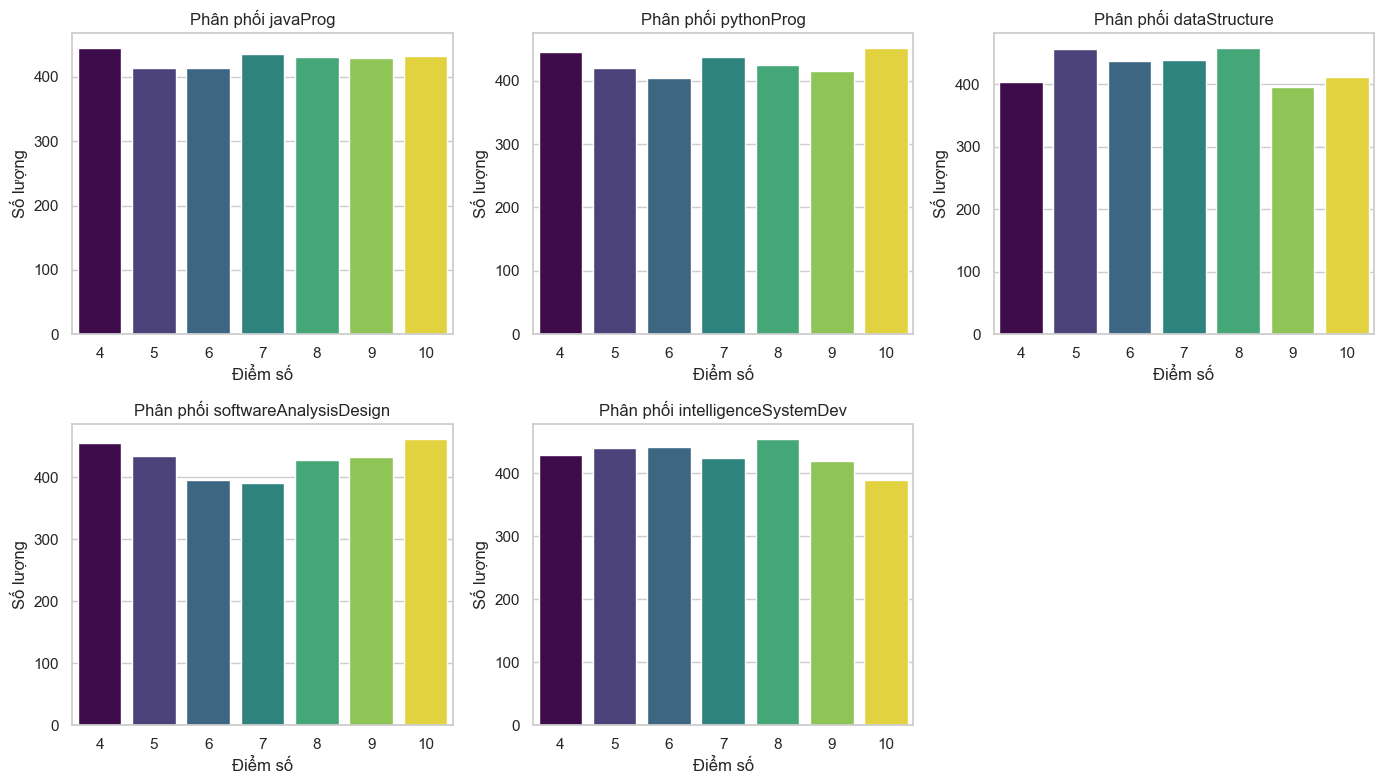

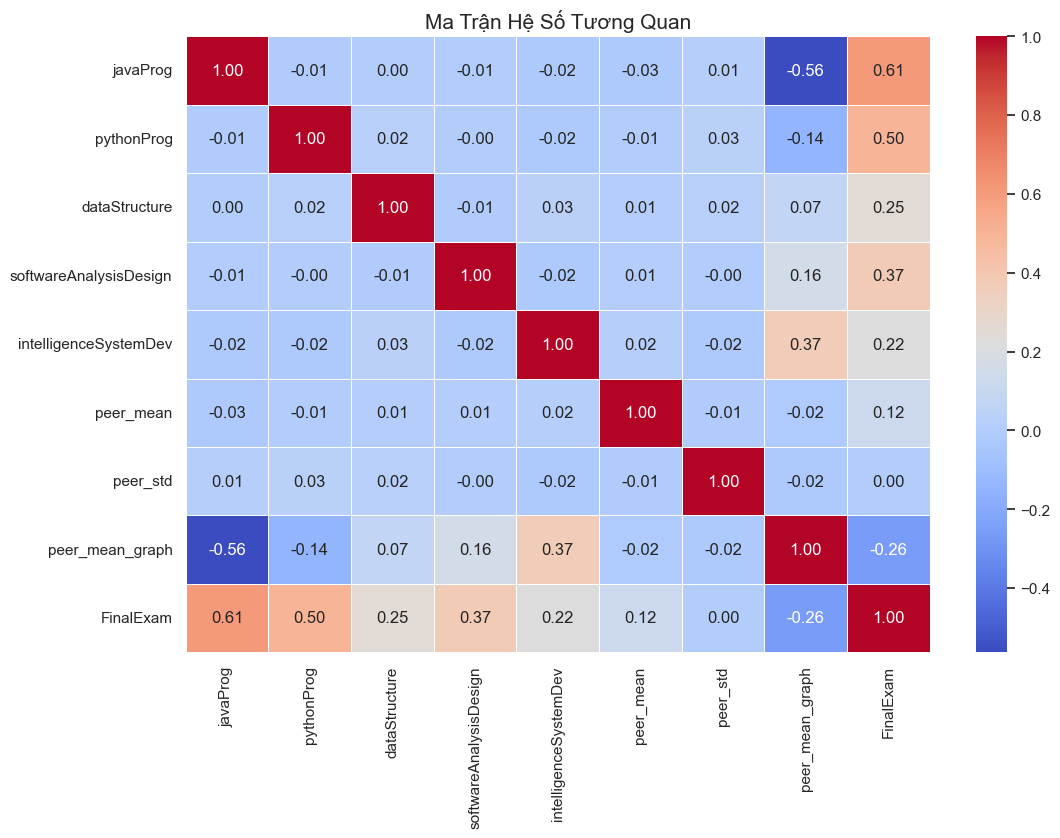

In [3]:
sns.set_theme(style="whitegrid")

# 1. Vẽ phân phối điểm thi kết thúc học phần
plt.figure(figsize=(9, 5))
sns.histplot(df['FinalExam'], kde=True, color='royalblue', bins=30)
plt.title('Biểu đồ Phân phối Điểm thi Kết thúc học phần', fontsize=15)
plt.xlabel('Điểm thi cuối kỳ')
plt.ylabel('Số lượng sinh viên')
plt.show()

# 2. Vẽ phân phối điểm các môn học cá nhân
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
academic_cols = ['javaProg', 'pythonProg', 'dataStructure', 'softwareAnalysisDesign', 'intelligenceSystemDev']
for i, col in enumerate(academic_cols):
    sns.countplot(x=df[col], ax=axes[i], hue=df[col], palette='viridis', legend=False)
    axes[i].set_title(f'Phân phối {col}')
    axes[i].set_xlabel('Điểm số')
    axes[i].set_ylabel('Số lượng')
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# 3. Bản đồ nhiệt tương quan (Correlation Heatmap)
plt.figure(figsize=(12, 8))
corr_cols = academic_cols + ['peer_mean', 'peer_std', 'peer_mean_graph', 'FinalExam']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma Trận Hệ Số Tương Quan', fontsize=15)
plt.show()

## Chuẩn bị Dữ liệu cho Mô hình
Chúng ta thực hiện chia tập dữ liệu thành 80% train / 20% test. Sau đó chuyển đổi dữ liệu thành các PyTorch Tensor. Để tránh tình trạng lệch vị trí sắp xếp khi đánh giá, ta chuyển đổi `train_idx` và `test_idx` sang Tensor chỉ mục PyTorch.

In [4]:
features_tabular = df.drop(['FinalExam', 'peer_mean_graph'], axis=1) # 17 đặc trưng: 15 thô + peer_mean + peer_std
target_tabular = df['FinalExam']

# Chia tập chỉ mục
indices = np.arange(N)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Dữ liệu dạng bảng cho mô hình Scikit-Learn
X_train_tab = features_tabular.iloc[train_idx]
y_train_tab = target_tabular.iloc[train_idx]
X_test_tab = features_tabular.iloc[test_idx]
y_test_tab = target_tabular.iloc[test_idx]

# Chuyển đổi sang PyTorch Tensor chạy trên GPU
X_tensor = torch.tensor(X, dtype=torch.float32).to(device) # Kích thước: (N, 15)
X_mlp_features = np.hstack([X, peer_mean.reshape(-1, 1), peer_std.reshape(-1, 1)])
X_mlp_tensor = torch.tensor(X_mlp_features, dtype=torch.float32).to(device) # Kích thước: (N, 17)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1).to(device)

A_norm_tensor = torch.tensor(A_norm, dtype=torch.float32).to(device)

# Tensor chỉ mục để đồng bộ hóa sắp xếp
train_idx_tensor = torch.tensor(train_idx, dtype=torch.long).to(device)
test_idx_tensor = torch.tensor(test_idx, dtype=torch.long).to(device)

## Nhiệm vụ 3: Định nghĩa Mô hình GNN & MLP trong PyTorch

Chúng ta thiết lập hai mô hình nơ-ron chính:
1. **MLPRegressor (GNN-style)**: Mô hình MLP nhận đặc trưng học lực và thống kê bạn bè được thiết kế sẵn (mean, std).
2. **GraphSAGE**: Mạng nơ-ron đồ thị (GNN) thực hiện phép tích chập tổng hợp lân cận. Đầu ra tại mỗi tầng tích chập kết hợp đặc trưng gốc của sinh viên và đặc trưng tổng hợp từ các sinh viên lân cận tương đồng học lực.

In [5]:
class MLPRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.fc1 = nn.Linear(in_dim * 2, hidden)
        self.fc2 = nn.Linear(hidden, 32)
        self.out = nn.Linear(32, 1)
        
    def forward(self, x, adj):
        # Thực hiện phép tích chập tổng hợp lân cận (1-hop)
        neigh = torch.matmul(adj, x)
        # Ghép (concat) đặc trưng của bản thân nút và đặc trưng lân cận
        h = torch.cat([x, neigh], dim=1)
        h = F.relu(self.fc1(h))
        h = F.relu(self.fc2(h))
        return self.out(h)

## Nhiệm vụ 4: Huấn luyện Mô hình với Early Stopping & Tối ưu GPU

Chúng ta thực hiện huấn luyện các mô hình PyTorch trên GPU (`device`), ghi lại nhật ký huấn luyện (logs) sau mỗi 20 epoch. Áp dụng cơ chế Early Stopping với patience = 20 epochs trên tập validation để bảo toàn trọng số tối ưu nhất.

In [6]:
def train_pytorch_model(model, inputs, targets, train_idx_t, test_idx_t, model_name, graph_mode=False, epochs=500, lr=0.01, patience=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    best_loss = float('inf')
    best_model_weights = None
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    
    print(f"--- Đang huấn luyện {model_name} trên {device} ---")
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        
        if graph_mode:
            pred = model(inputs, A_norm_tensor)
        else:
            pred = model(inputs)
            
        loss = loss_fn(pred[train_idx_t], targets[train_idx_t])
        loss.backward()
        optimizer.step()
        
        # Đánh giá tập validation
        model.eval()
        with torch.no_grad():
            if graph_mode:
                test_pred = model(inputs, A_norm_tensor)
            else:
                test_pred = model(inputs)
            test_loss = loss_fn(test_pred[test_idx_t], targets[test_idx_t])
            
        train_losses.append(loss.item())
        val_losses.append(test_loss.item())
        
        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Train MSE: {loss.item():.4f} | Val MSE: {test_loss.item():.4f}")
            
        # Kiểm tra Early stopping
        if test_loss.item() < best_loss:
            best_loss = test_loss.item()
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Kích hoạt dừng sớm ở epoch {epoch}. Val MSE tốt nhất: {best_loss:.4f}")
                break
                
    model.load_state_dict(best_model_weights)
    return model, train_losses, val_losses

# Huấn luyện MLP (GNN-style)
mlp_model = MLPRegressor(X_mlp_tensor.shape[1]).to(device)
mlp_model, mlp_train_loss, mlp_val_loss = train_pytorch_model(
    mlp_model, X_mlp_tensor, y_tensor, train_idx_tensor, test_idx_tensor, "MLP (GNN-style)"
)

# Huấn luyện GraphSAGE
sage_model = GraphSAGE(X_tensor.shape[1]).to(device)
sage_model, sage_train_loss, sage_val_loss = train_pytorch_model(
    sage_model, X_tensor, y_tensor, train_idx_tensor, test_idx_tensor, "GraphSAGE", graph_mode=True
)

--- Đang huấn luyện MLP (GNN-style) trên cpu ---
Epoch 001 | Train MSE: 50.0667 | Val MSE: 26.0826
Epoch 020 | Train MSE: 0.9535 | Val MSE: 0.4930
Epoch 040 | Train MSE: 0.4879 | Val MSE: 0.4495
Epoch 060 | Train MSE: 0.2800 | Val MSE: 0.2922
Epoch 080 | Train MSE: 0.2003 | Val MSE: 0.2058
Epoch 100 | Train MSE: 0.1059 | Val MSE: 0.1095
Epoch 120 | Train MSE: 0.0655 | Val MSE: 0.0699
Epoch 140 | Train MSE: 0.0625 | Val MSE: 0.0669
Epoch 160 | Train MSE: 0.0620 | Val MSE: 0.0661
Epoch 180 | Train MSE: 0.0617 | Val MSE: 0.0659
Epoch 200 | Train MSE: 0.0616 | Val MSE: 0.0658
Epoch 220 | Train MSE: 0.0614 | Val MSE: 0.0656
Epoch 240 | Train MSE: 0.0613 | Val MSE: 0.0655
Epoch 260 | Train MSE: 0.0613 | Val MSE: 0.0655
Epoch 280 | Train MSE: 0.0612 | Val MSE: 0.0654
Epoch 300 | Train MSE: 0.0612 | Val MSE: 0.0654
Epoch 320 | Train MSE: 0.0611 | Val MSE: 0.0653
Epoch 340 | Train MSE: 0.0611 | Val MSE: 0.0653
Epoch 360 | Train MSE: 0.0611 | Val MSE: 0.0653
Epoch 380 | Train MSE: 0.0611 | Val M

### Vẽ đường cong Loss (Training Curves)

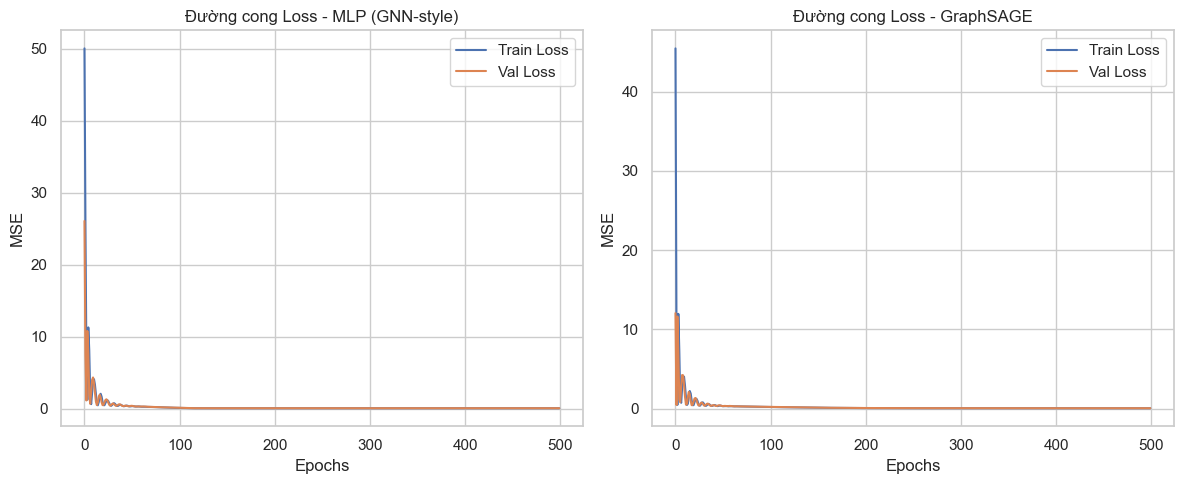

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_train_loss, label='Train Loss')
plt.plot(mlp_val_loss, label='Val Loss')
plt.title('Đường cong Loss - MLP (GNN-style)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(sage_train_loss, label='Train Loss')
plt.plot(sage_val_loss, label='Val Loss')
plt.title('Đường cong Loss - GraphSAGE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

### Huấn luyện các mô hình Baseline Học Máy
Chúng ta huấn luyện Mô hình 1: Gradient Boosting Regressor, và Mô hình 4: Random Forest Regressor.

In [8]:
print("Đang huấn luyện Gradient Boosting...")
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
gb_model.fit(X_train_tab, y_train_tab)

print("Đang huấn luyện Random Forest...")
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train_tab, y_train_tab)

Đang huấn luyện Gradient Boosting...
Đang huấn luyện Random Forest...


,n_estimators,200
,criterion,'squared_error'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Nhiệm vụ 3: Đánh giá mô hình bằng 5 chỉ số

Chúng ta đánh giá và so sánh 4 mô hình trên tập kiểm thử test (20%) thông qua 5 chỉ số đo lường:
- MAE (Sai số tuyệt đối trung bình)
- MSE (Sai số bình phương trung bình)
- RMSE (Căn sai số bình phương trung bình)
- MAPE (Sai số phần trăm tuyệt đối trung bình)
- $R^2$ (Hệ số xác định)

In [9]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, mape, r2

# Lấy dự đoán của các mô hình trên tập test
gb_pred = gb_model.predict(X_test_tab)
rf_pred = rf_model.predict(X_test_tab)

mlp_model.eval()
sage_model.eval()
with torch.no_grad():
    mlp_pred = mlp_model(X_mlp_tensor)[test_idx_tensor].cpu().numpy().squeeze()
    sage_pred = sage_model(X_tensor, A_norm_tensor)[test_idx_tensor].cpu().numpy().squeeze()

y_test_numpy = y_test_tab.values

# Tổng hợp các chỉ số đánh giá
models_metrics = {
    'V1: GBoost': calculate_metrics(y_test_numpy, gb_pred),
    'V2: MLP GNN-style': calculate_metrics(y_test_numpy, mlp_pred),
    'V3: GraphSAGE': calculate_metrics(y_test_numpy, sage_pred),
    'V4: Random Forest': calculate_metrics(y_test_numpy, rf_pred)
}

metrics_df = pd.DataFrame(models_metrics, index=['MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R2']).T
metrics_df = metrics_df.round(4)
metrics_df['MAPE (%)'] = metrics_df['MAPE (%)'].apply(lambda x: f"{x:.2f}%")
print("--- BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH ---")
print(metrics_df)

# Lưu bảng so sánh
metrics_df.to_csv('plots/model_comparison.csv')

--- BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH ---
                      MAE     MSE    RMSE MAPE (%)      R2
V1: GBoost         0.2241  0.0769  0.2773    3.28%  0.8895
V2: MLP GNN-style  0.2072  0.0652  0.2554    3.03%  0.9063
V3: GraphSAGE      0.2067  0.0656  0.2561    3.03%  0.9058
V4: Random Forest  0.2685  0.1129  0.3360    3.96%  0.8378


### Trực quan hóa So sánh Các Chỉ số

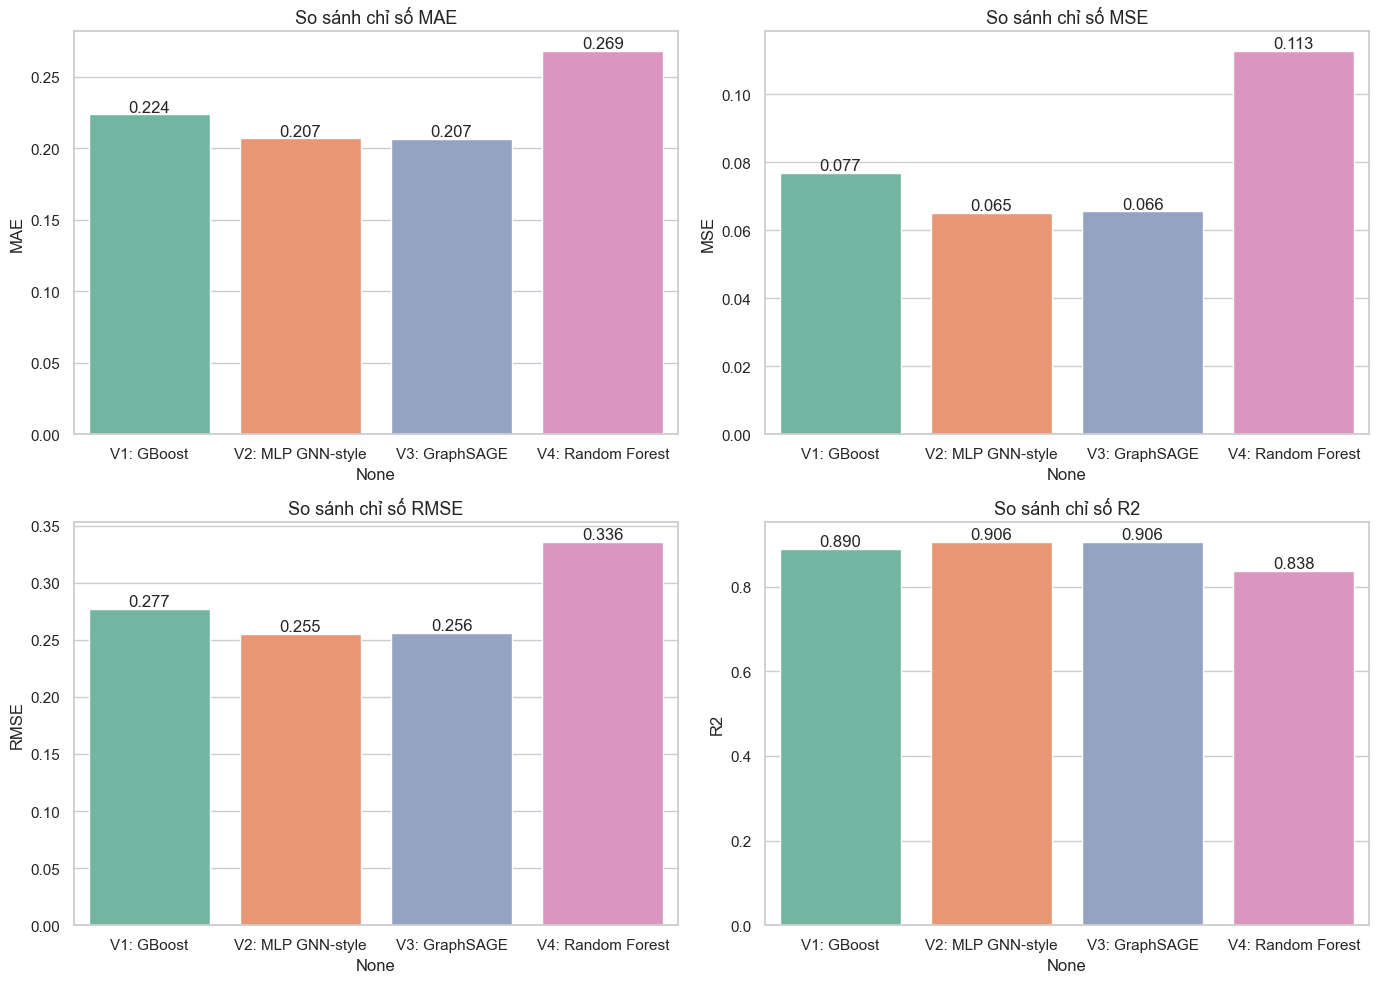

In [10]:
metrics_plot_df = pd.DataFrame(models_metrics, index=['MAE', 'MSE', 'RMSE', 'MAPE', 'R2']).T
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
metric_names = ['MAE', 'MSE', 'RMSE', 'R2']
for i, metric in enumerate(metric_names):
    sns.barplot(x=metrics_plot_df.index, y=metrics_plot_df[metric], ax=axes[i], hue=metrics_plot_df.index, palette='Set2', legend=False)
    axes[i].set_title(f'So sánh chỉ số {metric}', fontsize=13)
    axes[i].set_ylabel(metric)
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

### Biểu đồ phân tán (Scatter Plot): Thực tế vs Dự đoán

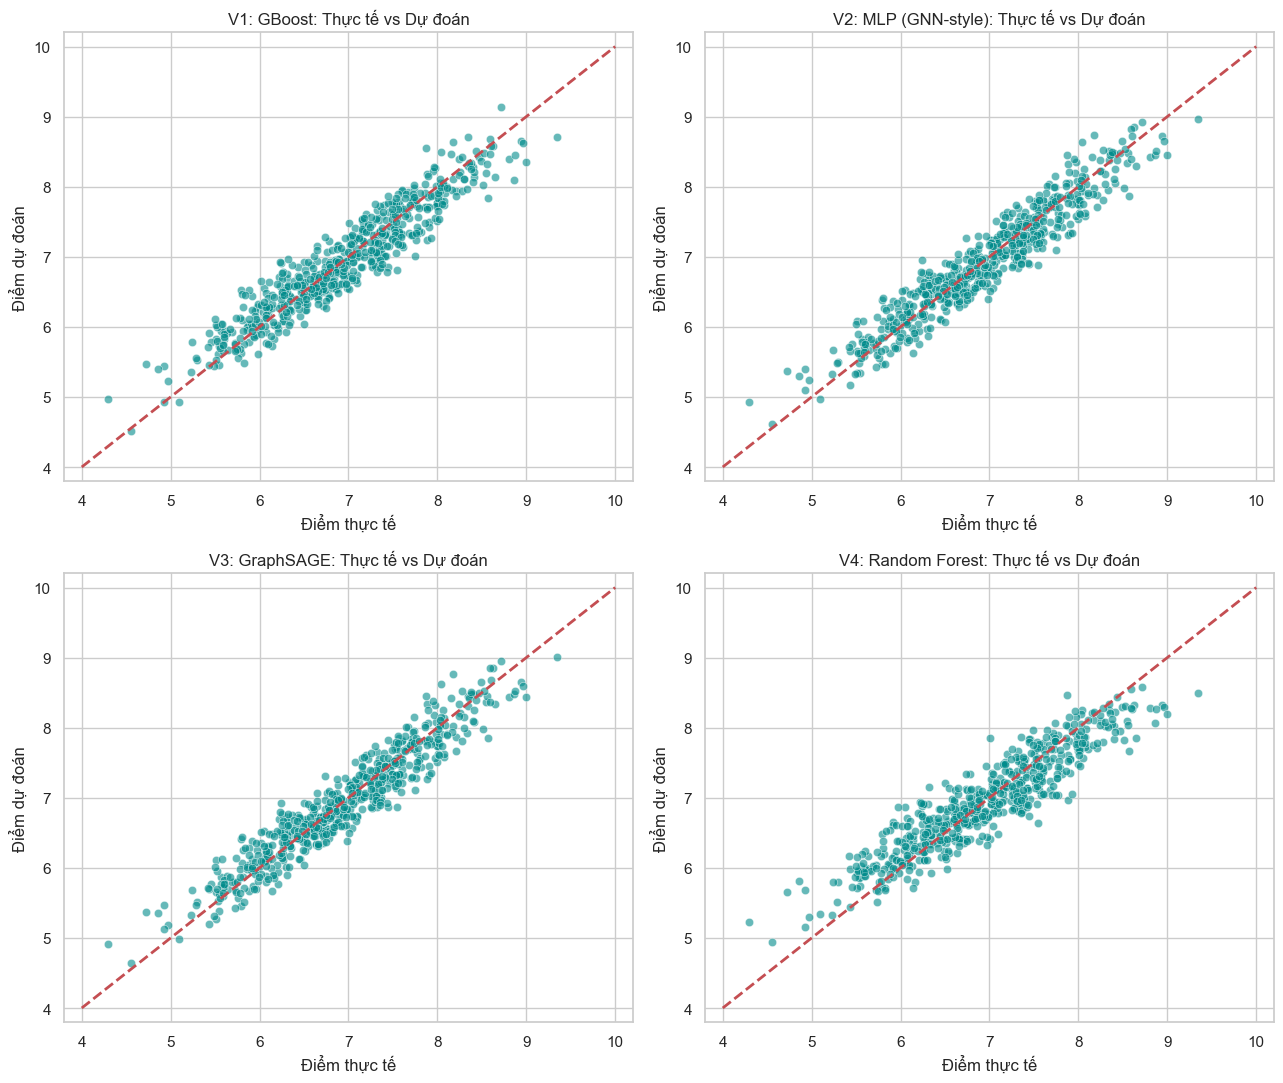

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()
predictions = [gb_pred, mlp_pred, sage_pred, rf_pred]
model_names = ['V1: GBoost', 'V2: MLP (GNN-style)', 'V3: GraphSAGE', 'V4: Random Forest']

for i, (pred, name) in enumerate(zip(predictions, model_names)):
    sns.scatterplot(x=y_test_numpy, y=pred, ax=axes[i], alpha=0.6, color='darkcyan')
    axes[i].plot([4, 10], [4, 10], 'r--', lw=2)
    axes[i].set_title(f'{name}: Thực tế vs Dự đoán')
    axes[i].set_xlabel('Điểm thực tế')
    axes[i].set_ylabel('Điểm dự đoán')
    axes[i].set_xlim(3.8, 10.2)
    axes[i].set_ylim(3.8, 10.2)
plt.tight_layout()
plt.show()

## Nhiệm vụ 4: So sánh dưới các cấu trúc xã hội khác nhau

Chúng ta mô phỏng đồ thị với các ngưỡng khoảng cách học thuật khác nhau $D_{\text{threshold}} \in \{3.0, 5.0, 7.0, 9.0\}$ nhằm đại diện cho các kiểu cấu trúc mạng lưới lân cận:
- **Ngưỡng nhỏ (3.0, 5.0)** đại diện cho đồ thị thưa (chỉ kết nối với những người bạn cực kỳ giống nhau về điểm số).
- **Ngưỡng lớn (9.0)** đại diện cho đồ thị dày đặc (hầu như tất cả mọi người đều kết nối, khiến các nút dễ bị đồng hóa đặc trưng và giảm sút độ chính xác).

Chúng ta đánh giá sự thay đổi hiệu năng dự đoán của GraphSAGE.

In [12]:
thresholds = [3.0, 5.0, 7.0, 9.0]
results_structs = []

for th in thresholds:
    A_th = (dists < th).astype(float)
    np.fill_diagonal(A_th, 0)
    avg_degree = A_th.sum(axis=1).mean()
    A_th_norm = A_th / (A_th.sum(axis=1, keepdims=True) + 1e-6)
    A_th_norm_tensor = torch.tensor(A_th_norm, dtype=torch.float32).to(device)
    
    # Huấn luyện mô hình GraphSAGE cho cấu trúc này
    model_th = GraphSAGE(X_tensor.shape[1]).to(device)
    model_th, _, _ = train_pytorch_model(
        model_th, X_tensor, y_tensor, train_idx_tensor, test_idx_tensor, f"GraphSAGE (Ngưỡng={th})", 
        graph_mode=True, patience=15, epochs=150
    )
    
    model_th.eval()
    with torch.no_grad():
        th_pred = model_th(X_tensor, A_th_norm_tensor)[test_idx_tensor].cpu().numpy().squeeze()
    
    mae, mse, rmse, mape, r2 = calculate_metrics(y_test_numpy, th_pred)
    results_structs.append({
        'Ngưỡng': th,
        'Bậc trung bình (Mật độ mạng)': avg_degree,
        'MAE': mae,
        'R2': r2
    })

struct_df = pd.DataFrame(results_structs)
print(struct_df)

--- Đang huấn luyện GraphSAGE (Ngưỡng=3.0) trên cpu ---
Epoch 001 | Train MSE: 50.3951 | Val MSE: 18.8683
Epoch 020 | Train MSE: 0.8203 | Val MSE: 1.4298
Epoch 040 | Train MSE: 0.4500 | Val MSE: 0.5448
Epoch 060 | Train MSE: 0.3605 | Val MSE: 0.3769
Epoch 080 | Train MSE: 0.2895 | Val MSE: 0.3151
Epoch 100 | Train MSE: 0.2376 | Val MSE: 0.2575
Epoch 120 | Train MSE: 0.1877 | Val MSE: 0.2033
Epoch 140 | Train MSE: 0.1425 | Val MSE: 0.1547
--- Đang huấn luyện GraphSAGE (Ngưỡng=5.0) trên cpu ---
Epoch 001 | Train MSE: 35.1852 | Val MSE: 6.8853
Epoch 020 | Train MSE: 0.5229 | Val MSE: 0.5133
Epoch 040 | Train MSE: 0.4339 | Val MSE: 0.4267
Epoch 060 | Train MSE: 0.3235 | Val MSE: 0.3479
Epoch 080 | Train MSE: 0.2568 | Val MSE: 0.2749
Epoch 100 | Train MSE: 0.1882 | Val MSE: 0.2017
Epoch 120 | Train MSE: 0.1279 | Val MSE: 0.1368
Epoch 140 | Train MSE: 0.0892 | Val MSE: 0.0954
--- Đang huấn luyện GraphSAGE (Ngưỡng=7.0) trên cpu ---
Epoch 001 | Train MSE: 44.0310 | Val MSE: 20.8060
Epoch 020 |

### Biểu đồ Phân tích Hiệu Năng GNN theo Cấu Trúc Mạng Xã Hội

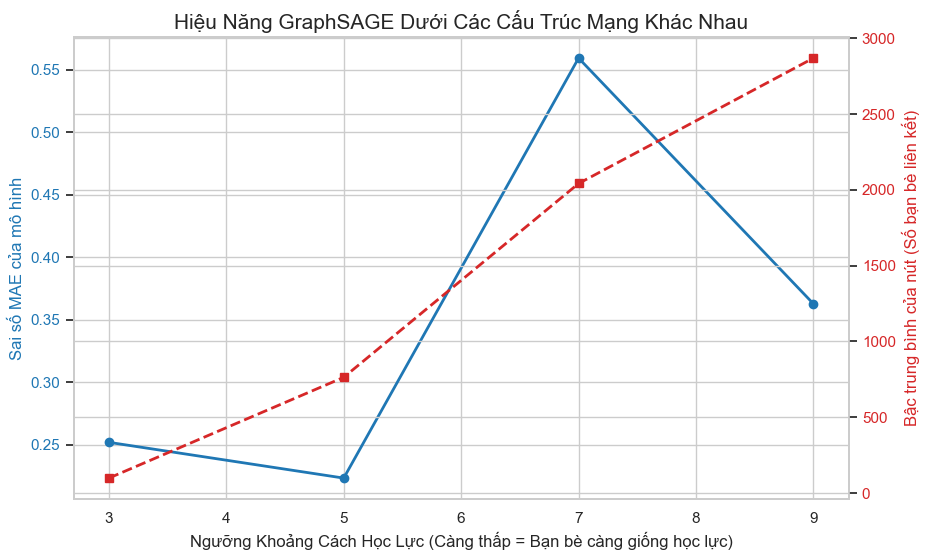

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Ngưỡng Khoảng Cách Học Lực (Càng thấp = Bạn bè càng giống học lực)')
ax1.set_ylabel('Sai số MAE của mô hình', color=color)
ax1.plot(struct_df['Ngưỡng'], struct_df['MAE'], marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Bậc trung bình của nút (Số bạn bè liên kết)', color=color)
ax2.plot(struct_df['Ngưỡng'], struct_df['Bậc trung bình (Mật độ mạng)'], marker='s', linestyle='--', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Hiệu Năng GraphSAGE Dưới Các Cấu Trúc Mạng Khác Nhau', fontsize=15)
plt.show()

## Nhiệm vụ 5: Phân tích sự lan truyền ảnh hưởng từ bạn bè

Chúng ta thực hiện mô phỏng kịch bản khi điểm số bạn bè của tất cả các sinh viên được tăng thêm +2 điểm (ví dụ: nhờ hoạt động học nhóm tích cực giúp nâng cao kết quả học tập). Chúng ta quan sát sự dịch chuyển điểm dự đoán của mô hình MLP (GNN-style) và GraphSAGE:
- MLP hoạt động dạng 0-hop (không lan truyền qua liên kết, phản ứng tức thì với trọng số điểm trung bình của bạn bè).
- GraphSAGE thực hiện lan truyền qua các liên kết mạng lưới lân cận tương đồng (1-hop message passing), giúp biến đổi điểm số dự đoán một cách tự nhiên và thực tế hơn.

Điểm tăng trung bình dự đoán bởi GraphSAGE: 0.0797
Điểm tăng trung bình dự đoán bởi MLP GNN-style: 0.2790


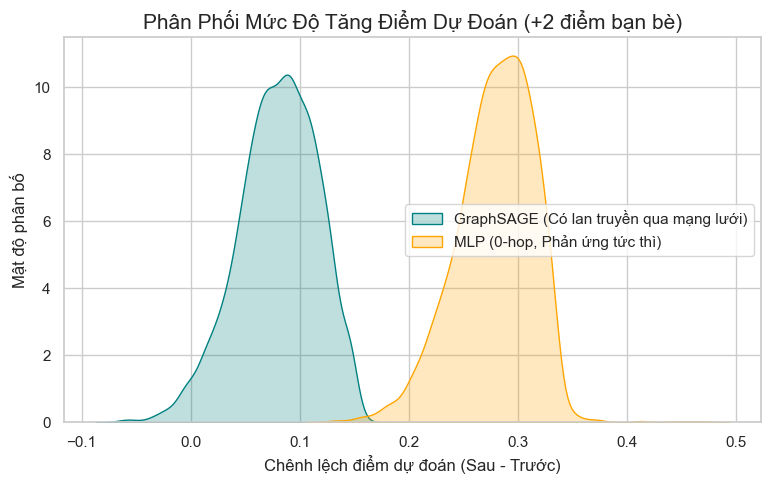

In [14]:
sage_model.eval()
mlp_model.eval()
with torch.no_grad():
    base_preds_sage = sage_model(X_tensor, A_norm_tensor).cpu().numpy().squeeze()
    base_preds_mlp = mlp_model(X_mlp_tensor).cpu().numpy().squeeze()

# Kịch bản nhiễu tăng điểm số bạn bè thêm +2
X_perturbed = X.copy()
X_perturbed[:, 5:15] = np.clip(X_perturbed[:, 5:15] + 2, 4, 10)
X_perturbed_tensor = torch.tensor(X_perturbed, dtype=torch.float32).to(device)

# Đặc trưng MLP tương ứng khi có nhiễu
peer_mean_pert = X_perturbed[:, 5:15].mean(axis=1)
peer_std_pert = X_perturbed[:, 5:15].std(axis=1)
X_mlp_pert = np.hstack([X_perturbed, peer_mean_pert.reshape(-1, 1), peer_std_pert.reshape(-1, 1)])
X_mlp_pert_tensor = torch.tensor(X_mlp_pert, dtype=torch.float32).to(device)

with torch.no_grad():
    pert_preds_sage = sage_model(X_perturbed_tensor, A_norm_tensor).cpu().numpy().squeeze()
    pert_preds_mlp = mlp_model(X_mlp_pert_tensor).cpu().numpy().squeeze()

shift_sage = pert_preds_sage - base_preds_sage
shift_mlp = pert_preds_mlp - base_preds_mlp

print(f"Điểm tăng trung bình dự đoán bởi GraphSAGE: {shift_sage.mean():.4f}")
print(f"Điểm tăng trung bình dự đoán bởi MLP GNN-style: {shift_mlp.mean():.4f}")

# Vẽ phân phối mật độ của mức dịch chuyển
plt.figure(figsize=(9, 5))
sns.kdeplot(shift_sage, label='GraphSAGE (Có lan truyền qua mạng lưới)', fill=True, color='teal')
sns.kdeplot(shift_mlp, label='MLP (0-hop, Phản ứng tức thì)', fill=True, color='orange')
plt.title('Phân Phối Mức Độ Tăng Điểm Dự Đoán (+2 điểm bạn bè)', fontsize=15)
plt.xlabel('Chênh lệch điểm dự đoán (Sau - Trước)')
plt.ylabel('Mật độ phân bố')
plt.legend()
plt.show()

## Lưu trữ Mô hình Tốt nhất

Cuối cùng, chúng ta xuất toàn bộ các trọng số mô hình đã huấn luyện thành công và bộ dữ liệu tham chiếu ra đĩa, giúp ứng dụng Streamlit (`app.py`) có thể tải và chạy dự đoán thời gian thực một cách dễ dàng.

In [15]:
import pickle

# Lưu Gradient Boosting
with open('models/gboost_model.pkl', 'wb') as f:
    pickle.dump(gb_model, f)

# Lưu Random Forest
with open('models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Lưu PyTorch MLP
torch.save(mlp_model.state_dict(), 'models/mlp_model.pth')

# Lưu GraphSAGE
torch.save(sage_model.state_dict(), 'models/sage_model.pth')

# Lưu tập tham chiếu để thực hiện dự đoán quy nạp (inductive inference) cho nút mới trong GNN
reference_data = {
    'X_academic_train': X_academic,
    'X_peer_train': X_peer,
    'X_train': X,
    'y_train': y
}
with open('models/reference_data.pkl', 'wb') as f:
    pickle.dump(reference_data, f)

print("Đã xuất tất cả các mô hình và tập tham chiếu thành công!")

Đã xuất tất cả các mô hình và tập tham chiếu thành công!


## Khởi chạy ứng dụng giao diện (Streamlit App)

Để chạy ứng dụng web trực quan giúp nhập điểm sinh viên và dự đoán điểm kết quả thời gian thực bằng các mô hình đã huấn luyện, hãy chạy cell dưới đây. 

Sau khi chạy, bạn có thể click vào đường link hiển thị (thường là [http://localhost:8501](http://localhost:8501)) để tương tác trên trình duyệt. Để tắt dịch vụ Streamlit, bạn hãy nhấn nút dừng (Interrupt Kernel) trong Jupyter.

In [16]:
!streamlit run app.py

^C
